# 아키텍처별 런타임 평가

`models_<arch>/<svc>/`의 모델로 서비스별 탐지 성능을 비교
- 세션별 윈도우는 5개 패킷, stride는 1
- 점수가 `threshold_df`보다 낮으면 이상으로 판정
- 재보정하지 않은 모델은 학습 시점 임계값을 사용하며 `ROLLBK`로 표시

## 모델 확인

`models_*`를 찾아 모델 파일, 재보정 여부, 임계값을 확인한다.

In [2]:
import os, sys, json, collections, warnings, re
from pathlib import Path

warnings.filterwarnings("ignore")
import numpy as np

# 현재 작업 디렉터리 기준
ROOT = Path.cwd()

SERVICES = ["auth", "post", "comment", "frontend"]
REMOVED_SERVICES = ["mysql"]

# 모델: models_<arch>/<svc>/, 컨버터: <svc>/<svc>_converter.py
PCAP_ROOT = ROOT / "test_pcap_notrecal"

def arch_dir(arch):        return ROOT / f"models_{arch}"
def arch_svc_dir(arch, s): return ROOT / f"models_{arch}" / s

# 사용 가능한 모델 탐색
_ORDER = ["1x8", "2x8", "1x16", "2x16", "2x32"]
_found = {p.name[len("models_"):] for p in ROOT.glob("models_*") if p.is_dir()}
ARCHS = [a for a in _ORDER if a in _found] + sorted(_found - set(_ORDER))

if not ARCHS:
    raise FileNotFoundError(f"models_<arch>/ 디렉터리가 없습니다: {ROOT}")

# 필수 파일과 재보정 상태 확인
_problems = []
ARCH_STATUS = {}          # 아키텍처별 서비스 상태

for _svc in SERVICES:
    if not (ROOT / _svc / f"{_svc}_converter.py").is_file():
        _problems.append(f"컨버터 없음: {_svc}/{_svc}_converter.py")
for _f in ("converter.py", "converter_common.py", "detector.py", "handler.py"):
    if not (ROOT / _f).is_file():
        _problems.append(f"루트 공유 모듈 없음: {_f}")
for _d in ("benign", "attack"):
    if not (PCAP_ROOT / _d).is_dir():
        _problems.append(f"pcap 디렉터리 없음: test_pcap_notrecal/{_d}/")

for _a in ARCHS:
    ARCH_STATUS[_a] = {}
    for _svc in SERVICES:
        d = arch_svc_dir(_a, _svc)
        if not d.is_dir():
            _problems.append(f"모델 디렉터리 없음: models_{_a}/{_svc}/"); continue
        if not (d / "student_ts.pt").is_file():
            _problems.append(f"인코더 없음: models_{_a}/{_svc}/student_ts.pt")
        for _f in ("ocsvm.pkl", "threshold.json"):
            if not (d / _f).is_file():
                _problems.append(f"모델 파일 없음: models_{_a}/{_svc}/{_f}")
        if (d / "threshold.json").is_file():
            m = json.loads((d / "threshold.json").read_text(encoding="utf-8"))
            ARCH_STATUS[_a][_svc] = {
                "recalibrated": bool(m.get("recalibrated")),
                "thr": m.get("threshold_df"),
                "arch": m.get("arch"),
                "vec_len": m.get("vec_len"),
            }

if _problems:
    raise FileNotFoundError("구조 문제:\n  - " + "\n  - ".join(_problems))

print("ROOT      =", ROOT)
print("PCAP_ROOT =", PCAP_ROOT)
print("SERVICES  =", SERVICES, f"(제거됨: {REMOVED_SERVICES})")
print("ARCHS     =", ARCHS)

print(f"\n{'arch':8s}" + "".join(f"{s:>14s}" for s in SERVICES))
print("-" * (8 + 14 * len(SERVICES)))
for _a in ARCHS:
    line = f"{_a:8s}"
    for _svc in SERVICES:
        st = ARCH_STATUS[_a][_svc]
        line += f"{('OK' if st['recalibrated'] else 'ROLLBK'):>7s}{st['thr']:7.1f}"
    print(line)
print("\nOK=재보정본 / ROLLBK=학습 시점 임계값(운영 성능 아님, 참고용으로만 비교)")


ROOT      = c:\new_test
PCAP_ROOT = c:\new_test\test_pcap_notrecal
SERVICES  = ['auth', 'post', 'comment', 'frontend'] (제거됨: ['mysql'])
ARCHS     = ['1x8', '2x8', '1x16', '2x16', '2x32']

arch              auth          post       comment      frontend
----------------------------------------------------------------
1x8      ROLLBK  -18.3     OK  -29.3 ROLLBK   -3.7 ROLLBK   -0.6
2x8          OK   -3.4     OK   -0.5     OK   -0.3 ROLLBK -114.4
1x16         OK   -0.8     OK   -4.3 ROLLBK  -19.1 ROLLBK  -13.6
2x16         OK   -3.8     OK  -57.4     OK   -0.9 ROLLBK -290.7
2x32         OK   -1.1     OK   -1.1 ROLLBK   -6.1 ROLLBK  -39.4

OK=재보정본 / ROLLBK=학습 시점 임계값(운영 성능 아님, 참고용으로만 비교)


## 모델 로드

`sweep_detector`로 `models_<arch>/<svc>/`의 모델을 불러온다. 첫 모델로 로드를 확인한다.

In [ ]:
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import converter as _conv_mod
from converter import (
    Converter, read_pcap, Packet, WIN_SIZE, FEAT_LEN, SVC_KIND,
    ACTIVE_SERVICES, MODULE_FILES,
)
from handler import Handler, ACT_FORWARD, ACT_RECORD_REQUEST, ACT_TRIGGER_RELAY
from detector import Detector as _BaseDetector


# 기본 Detector의 경로 대신 models_<arch>/<svc>/에서 로드
def sweep_detector(service, models_root=None, device="cpu", threshold_key="threshold_df"):
    """models_<arch>/<svc>/에서 Detector를 구성한다."""
    if models_root is None:
        raise ValueError("models_root 필요 (models_<arch> 경로)")
    import os as _os, json as _json
    import detector as _dm
    import torch as _torch
    svc_dir = _os.path.join(str(models_root), service)
    if not _os.path.isdir(svc_dir):
        raise FileNotFoundError(f"model dir not found: {svc_dir} (기대: models_<arch>/{service}/)")
    det = _dm.Detector.__new__(_dm.Detector)
    det._torch = _torch
    det.service = service
    det.device = device
    det.model_dir = svc_dir
    with open(_os.path.join(svc_dir, "threshold.json"), encoding="utf-8") as f:
        thr_obj = _json.load(f)
    det.encoder, det.encoder_source = _dm._load_encoder(
        svc_dir, str(thr_obj.get("arch", "")), device, _torch)
    det.ocsvm = _dm._load_ocsvm(_os.path.join(svc_dir, "ocsvm.pkl"))
    det.threshold = float(thr_obj[threshold_key])
    det.meta = thr_obj
    det.eval_meta = {}
    _ev = _os.path.join(svc_dir, "eval_results.json")
    if _os.path.isfile(_ev):
        with open(_ev, encoding="utf-8") as f:
            det.eval_meta = _json.load(f)
    _vec = thr_obj.get("vec_len")
    if _vec is not None and int(_vec) != _dm.FEAT_LEN:
        raise ValueError(f"{service}: threshold.json vec_len={_vec} != FEAT_LEN={_dm.FEAT_LEN}")
    return det


sweep_detector.__sweep_wrapper__ = True


print("converter 파사드 :", _conv_mod.__file__)
print("FEAT_LEN / WIN_SIZE :", FEAT_LEN, "/", WIN_SIZE)
for _svc in SERVICES:
    _cls = _conv_mod.REGISTRY[_svc]
    print(f"  {_svc:9s} {_cls.__name__:18s} kind={_cls.KIND:9s} {MODULE_FILES[_svc]}")
assert set(ACTIVE_SERVICES) == set(SERVICES), (ACTIVE_SERVICES, SERVICES)

# 첫 모델 로드 확인
_probe = sweep_detector(SERVICES[0], models_root=str(arch_dir(ARCHS[0])))
print(f"\nDetector 확인: {ARCHS[0]}/{SERVICES[0]} "
      f"thr={_probe.threshold:+.4f}  encoder={_probe.encoder_source}")
del _probe


converter 파사드 : c:\new_test\converter.py
FEAT_LEN / WIN_SIZE : 20 / 5
  auth      AuthConverter      kind=flow      c:\new_test\auth\auth_converter.py
  post      PostConverter      kind=backend   c:\new_test\post\post_converter.py
  comment   CommentConverter   kind=backend   c:\new_test\comment\comment_converter.py
  frontend  FrontendConverter  kind=frontend  c:\new_test\frontend\frontend_converter.py

Detector 확인: 1x8/auth thr=-18.3193  encoder=TorchScript(student_ts.pt)


## 평가 대상

`PCAP_ROOT`의 PCAP을 읽고 mysql과 auth/post/comment의 d1을 제외한다.

In [5]:
from pathlib import Path
from collections import defaultdict

import numpy as np
from sklearn.metrics import roc_auc_score

from converter import Converter, read_pcap, WIN_SIZE
from detector import Detector

EVAL_TEST_PCAP   = PCAP_ROOT
# 모델 경로는 run_eval(arch)에서 지정
EVAL_MODELS_ROOT = None
EVAL_SERVICES    = list(SERVICES)

# 제외할 mysql PCAP도 파일명은 인식
KNOWN_SERVICES = list(SERVICES) + list(REMOVED_SERVICES)

# mysql과 백엔드 d1 제외
EXCLUDED_SERVICES = set(REMOVED_SERVICES)
EXCLUDED_ATTACK_SCENARIOS = {
    ("auth", "d1"),
    ("post", "d1"),
    ("comment", "d1"),
}

# 필수 시나리오 목록
EVAL_SCENS = {
    "auth":     ["cred_enum", "k1", "k2"],
    "post":     ["enum_seq", "l3", "l2", "k1", "k2"],
    "comment":  ["enum_seq", "l3", "l2", "k1", "k2"],
    "frontend": ["scan_seq", "r1", "k1", "k2"],
}

# 공격 패킷 앞뒤에 붙일 정상 패킷 수
EVAL_BENIGN_GAP = WIN_SIZE - 1


def _parse_attack_pcap(path: Path):
    stem = path.stem
    for svc in KNOWN_SERVICES:
        prefix = f"attack_{svc}_"
        if stem.startswith(prefix):
            scen = stem[len(prefix):]
            if scen:
                return svc, scen
    raise ValueError(f"공격 PCAP 이름을 해석할 수 없음: {path.name}")


def _parse_benign_pcap(path: Path):
    stem = path.stem
    for svc in KNOWN_SERVICES:
        if stem == f"benign_{svc}":
            return svc
    raise ValueError(f"benign PCAP 이름을 해석할 수 없음: {path.name}")


if not EVAL_TEST_PCAP.exists():
    raise FileNotFoundError(f"test_pcap 폴더 없음: {EVAL_TEST_PCAP.resolve()}")

# PCAP 수집
_eval_attack_paths = sorted((EVAL_TEST_PCAP / "attack").glob("*.pcap"))
_eval_benign_paths = sorted((EVAL_TEST_PCAP / "benign").glob("*.pcap"))

_all_attack = [(*_parse_attack_pcap(p), p) for p in _eval_attack_paths]
_all_benign = [(_parse_benign_pcap(p), p) for p in _eval_benign_paths]

# 제외 대상 분리
EVAL_ATTACK_FILES = []
_skipped_attack = []

for svc, scen, p in _all_attack:
    if svc in EXCLUDED_SERVICES:
        _skipped_attack.append((svc, scen, p, "서비스 제거됨"))
    elif (svc, scen) in EXCLUDED_ATTACK_SCENARIOS:
        _skipped_attack.append((svc, scen, p, "탐지 범위 밖(정책)"))
    else:
        EVAL_ATTACK_FILES.append((svc, scen, p))

EVAL_BENIGN_FILES = defaultdict(list)
_skipped_benign = []

for svc, p in _all_benign:
    if svc in EXCLUDED_SERVICES:
        _skipped_benign.append((svc, p, "서비스 제거됨"))
    else:
        EVAL_BENIGN_FILES[svc].append(p)

# 필수 공격 PCAP 확인
_expected = {(svc, scen) for svc, scens in EVAL_SCENS.items() for scen in scens
             if svc not in EXCLUDED_SERVICES and (svc, scen) not in EXCLUDED_ATTACK_SCENARIOS}
_actual = {(svc, scen) for svc, scen, _ in EVAL_ATTACK_FILES}
_missing = sorted(_expected - _actual)
if _missing:
    raise FileNotFoundError(f"EVAL_SCENS 에 정의됐지만 실제 PCAP 이 없는 항목: {_missing}")

# 서비스별 정상 PCAP 확인
_missing_benign = [svc for svc in EVAL_SERVICES if not EVAL_BENIGN_FILES.get(svc)]
if _missing_benign:
    raise FileNotFoundError(f"benign PCAP 이 없는 서비스: {_missing_benign}")

# 인식하지 못한 PCAP 확인
_all_pcaps   = {p.resolve() for p in EVAL_TEST_PCAP.rglob("*.pcap")}
_recognized  = {p.resolve() for _, _, p in _all_attack}
_recognized |= {p.resolve() for _, p in _all_benign}
_unhandled = sorted(str(p) for p in (_all_pcaps - _recognized))
if _unhandled:
    raise RuntimeError(f"이름을 해석할 수 없는 PCAP 이 있음: {_unhandled}")

print(f"TEST_PCAP   = {EVAL_TEST_PCAP.resolve()}")
print(f"인식한 PCAP = {len(_all_pcaps)}개 "
      f"(benign={len(_eval_benign_paths)}, attack={len(_eval_attack_paths)})")
print(f"혼합 정책   = window {WIN_SIZE}개 중 benign {EVAL_BENIGN_GAP} + attack 1, stride=1")

print("\n[평가 제외]")
for svc, scen, p, why in _skipped_attack:
    print(f"  attack  {svc}/{scen:10s} {p.name:34s} — {why}")
for svc, p, why in _skipped_benign:
    print(f"  benign  {svc:17s} {p.name:34s} — {why}")
if not _skipped_attack and not _skipped_benign:
    print("  (없음)")

print("\n[실제 평가 대상]")
for svc in EVAL_SERVICES:
    scens = [scen for s, scen, _ in EVAL_ATTACK_FILES if s == svc]
    print(f"  {svc:9s}: benign {len(EVAL_BENIGN_FILES[svc])}개 / "
          f"attack {len(scens)}개 — {', '.join(scens)}")


TEST_PCAP   = C:\new_test\test_pcap_notrecal
인식한 PCAP = 29개 (benign=5, attack=24)
혼합 정책   = window 5개 중 benign 4 + attack 1, stride=1

[평가 제외]
  attack  auth/d1         attack_auth_d1.pcap                — 탐지 범위 밖(정책)
  attack  comment/d1         attack_comment_d1.pcap             — 탐지 범위 밖(정책)
  attack  mysql/c2         attack_mysql_c2.pcap               — 서비스 제거됨
  attack  mysql/e1         attack_mysql_e1.pcap               — 서비스 제거됨
  attack  mysql/k1         attack_mysql_k1.pcap               — 서비스 제거됨
  attack  mysql/k2         attack_mysql_k2.pcap               — 서비스 제거됨
  attack  post/d1         attack_post_d1.pcap                — 탐지 범위 밖(정책)
  benign  mysql             benign_mysql.pcap                  — 서비스 제거됨

[실제 평가 대상]
  auth     : benign 1개 / attack 3개 — cred_enum, k1, k2
  post     : benign 1개 / attack 5개 — enum_seq, k1, k2, l2, l3
  comment  : benign 1개 / attack 5개 — enum_seq, k1, k2, l2, l3
  frontend : benign 1개 / attack 4개 — k1, k2, r1, scan_seq


## 평가 함수

In [6]:
from collections import defaultdict, deque
from pathlib import Path

import numpy as np

# k1/k2는 패킷 하나씩 평가
SINGLE_PACKET_ATTACK_SCENS = {"k1", "k2"}


def _scenario_from_attack_source(source_name: str, svc: str):
    """attack_<svc>_<scen>.pcap에서 시나리오명을 추출한다."""
    stem = Path(source_name).stem
    prefix = f"attack_{svc}_"

    if stem.startswith(prefix):
        return stem[len(prefix):]

    # 형식이 다르면 파일명을 그대로 사용
    return stem


def _extract_session_vectors(svc: str, pcap_path: Path):
    """변환 가능한 패킷을 순서대로 세션별 벡터로 묶는다."""
    conv = Converter(svc)
    conv.reset()
    packets = read_pcap(str(pcap_path), "auto", limit=None)

    sessions = defaultdict(list)
    kept = 0

    for pkt in packets:
        r = conv.extract(pkt)
        if r is None:
            continue

        vec, _is_request = r
        sessions[pkt.session_id].append(vec.copy())
        kept += 1

    # 세션이 처음 등장한 순서 유지
    ordered = [(sid, vecs) for sid, vecs in sessions.items()]

    return ordered, {
        "pcap": pcap_path.name,
        "raw_egress_packets": len(packets),
        "kept_packets": kept,
        "sessions": len(ordered),
    }


def _score_pure_benign(svc: str, det, benign_sessions):
    """정상 세션별로 stride=1 윈도우를 평가한다."""
    image_conv = Converter(svc)
    scores = []
    per_session_images = []

    for source_name, sid, vecs in benign_sessions:
        n_img = max(0, len(vecs) - WIN_SIZE + 1)

        if n_img == 0:
            continue

        per_session_images.append((source_name, sid, n_img))

        for start in range(n_img):
            window = vecs[start:start + WIN_SIZE]
            img = image_conv.to_image(window)
            scores.append(det.score(img))

    return np.asarray(scores, dtype=np.float64), per_session_images


def _benign_context(vecs, start, n):
    """정상 세션에서 벡터 n개를 가져온다. 부족하면 순환한다."""
    if not vecs:
        raise ValueError("empty benign session")

    out = []
    pos = start % len(vecs)

    for _ in range(n):
        out.append(vecs[pos])
        pos = (pos + 1) % len(vecs)

    return out, pos


def _score_sequential_attack_session(svc, det, attack_vecs, benign_vecs, benign_start=0):
    """공격 세션 앞뒤에 정상 패킷을 붙여 평가한다."""
    image_conv = Converter(svc)
    scores = []

    occupancy_scores = defaultdict(list)

    prefix, pos = _benign_context(benign_vecs, benign_start, WIN_SIZE - 1)
    suffix, pos = _benign_context(benign_vecs, pos, WIN_SIZE - 1)

    # 패킷 라벨: 정상=0, 공격=1
    stream = (
        [(v, 0) for v in prefix]
        + [(v, 1) for v in attack_vecs]
        + [(v, 0) for v in suffix]
    )

    win_vec = deque(maxlen=WIN_SIZE)
    win_label = deque(maxlen=WIN_SIZE)

    for vec, label in stream:
        win_vec.append(vec)
        win_label.append(label)

        if len(win_vec) < WIN_SIZE:
            continue

        occupancy = int(sum(win_label))

        if occupancy <= 0:
            raise AssertionError(
                f"{svc}: sequential attack 평가에서 "
                f"pure benign window가 생성됨"
            )

        img = image_conv.to_image(list(win_vec))
        score = det.score(img)
        scores.append(score)
        occupancy_scores[occupancy].append(score)

    expected = len(attack_vecs) + WIN_SIZE - 1

    if len(scores) != expected:
        raise AssertionError(
            f"{svc}: sequential attack image 수 불일치: "
            f"actual={len(scores)}, expected={expected}"
        )

    return (
        np.asarray(scores, dtype=np.float64),
        {k: np.asarray(v, dtype=np.float64) for k, v in occupancy_scores.items()},
        pos,
    )


def _score_single_packet_attack_session(svc, det, attack_vecs, benign_vecs, benign_start=0):
    """k1/k2 공격 패킷 하나씩 정상 배경에 넣어 평가한다."""
    image_conv = Converter(svc)
    scores = []
    occupancy_scores = defaultdict(list)
    pos = benign_start

    for attack_vec in attack_vecs:
        prefix, pos = _benign_context(benign_vecs, pos, WIN_SIZE - 1)
        suffix, pos = _benign_context(benign_vecs, pos, WIN_SIZE - 1)

        stream = (
            [(v, 0) for v in prefix]
            + [(attack_vec, 1)]
            + [(v, 0) for v in suffix]
        )

        win_vec = deque(maxlen=WIN_SIZE)
        win_label = deque(maxlen=WIN_SIZE)
        this_attack_images = 0

        for vec, label in stream:
            win_vec.append(vec)
            win_label.append(label)

            if len(win_vec) < WIN_SIZE:
                continue

            occupancy = int(sum(win_label))

            if occupancy != 1:
                raise AssertionError(
                    f"{svc}: k1/k2 window의 "
                    f"attack occupancy={occupancy}, expected=1"
                )

            img = image_conv.to_image(list(win_vec))
            score = det.score(img)
            scores.append(score)
            occupancy_scores[1].append(score)
            this_attack_images += 1

        # 공격 패킷 하나당 WIN_SIZE개의 윈도우 생성
        if this_attack_images != WIN_SIZE:
            raise AssertionError(
                f"{svc}: single attack packet으로 "
                f"{this_attack_images}개 image 생성, expected={WIN_SIZE}"
            )

    expected = len(attack_vecs) * WIN_SIZE

    if len(scores) != expected:
        raise AssertionError(
            f"{svc}: k1/k2 image 수 불일치: "
            f"actual={len(scores)}, expected={expected}"
        )

    return (
        np.asarray(scores, dtype=np.float64),
        {1: np.asarray(occupancy_scores[1], dtype=np.float64)},
        pos,
    )


def _score_mixed_attack(svc: str, det, attack_sessions, benign_background_sessions):
    if not benign_background_sessions:
        raise RuntimeError(f"{svc}: mixed attack용 benign background session이 없음")

    scores_all = []
    pair_info = []
    occupancy_scores_all = defaultdict(list)
    attack_packets_used = 0
    mode_counts = defaultdict(int)

    for atk_idx, (attack_source, attack_sid, attack_vecs) in enumerate(attack_sessions):
        if not attack_vecs:
            continue

        scen = _scenario_from_attack_source(attack_source, svc)

        # 공격 세션 순서에 따라 정상 세션을 순환 배정
        bg_source, bg_sid, bg_vecs = benign_background_sessions[
            atk_idx % len(benign_background_sessions)
        ]

        if not bg_vecs:
            raise RuntimeError(f"{svc}: 빈 benign background session 선택됨")

        bg_start = (atk_idx * WIN_SIZE) % len(bg_vecs)

        if scen in SINGLE_PACKET_ATTACK_SCENS:
            mode = "single-packet"
            session_scores, occupancy_scores, _ = _score_single_packet_attack_session(
                svc, det, attack_vecs, bg_vecs, bg_start
            )

        else:
            mode = "sequential"
            session_scores, occupancy_scores, _ = _score_sequential_attack_session(
                svc, det, attack_vecs, bg_vecs, bg_start
            )

        scores_all.extend(session_scores.tolist())

        for occupancy, vals in occupancy_scores.items():
            occupancy_scores_all[occupancy].extend(vals.tolist())

        attack_packets_used += len(attack_vecs)
        mode_counts[mode] += 1

        occ_counts = {int(k): int(len(v)) for k, v in occupancy_scores.items()}

        pair_info.append({
            "scenario": scen,
            "mode": mode,
            "attack_source": attack_source,
            "attack_sid": attack_sid,
            "attack_packets": len(attack_vecs),
            "benign_source": bg_source,
            "benign_sid": bg_sid,
            "mixed_images": len(session_scores),
            "occupancy_counts": occ_counts,
        })

    occupancy_scores_np = {
        int(k): np.asarray(v, dtype=np.float64)
        for k, v in occupancy_scores_all.items()
    }

    return (
        np.asarray(scores_all, dtype=np.float64),
        {
            "attack_packets_used": attack_packets_used,
            "mixed_images": len(scores_all),
            "pairs": pair_info,

            "mode_counts": dict(mode_counts),

            # occupancy: 윈도우 내 공격 패킷 수
            "occupancy_scores": occupancy_scores_np,
            "occupancy_counts": {k: len(v) for k, v in occupancy_scores_np.items()},
        },
    )


def _safe_div(a, b):
    return float(a) / float(b) if b else float("nan")


def _metrics_from_scores(benign_scores, attack_scores, threshold):
    """공격을 양성으로 지표를 계산한다. score < threshold이면 이상이다."""
    benign_pred_anom = benign_scores < threshold
    attack_pred_anom = attack_scores < threshold

    FP = int(benign_pred_anom.sum())
    TN = int(len(benign_scores) - FP)
    TP = int(attack_pred_anom.sum())
    FN = int(len(attack_scores) - TP)

    recall = _safe_div(TP, TP + FN)
    fpr = _safe_div(FP, FP + TN)
    precision = _safe_div(TP, TP + FP)
    accuracy = _safe_div(TP + TN, TP + TN + FP + FN)

    if np.isfinite(precision) and np.isfinite(recall) and (precision + recall) > 0:
        f1 = 2 * precision * recall / (precision + recall)
    else:
        f1 = float("nan")

    if len(benign_scores) and len(attack_scores):
        y_true = np.r_[
            np.zeros(len(benign_scores), dtype=np.int8),
            np.ones(len(attack_scores), dtype=np.int8),
        ]

        # 낮은 점수가 이상이므로 AUC 계산 시 부호 반전
        y_score = np.r_[-benign_scores, -attack_scores]
        auc = float(roc_auc_score(y_true, y_score))
    else:
        auc = float("nan")

    return {
        "TP": TP, "FP": FP, "TN": TN, "FN": FN,
        "recall": recall, "fpr": fpr, "precision": precision,
        "accuracy": accuracy, "f1": f1, "auc": auc,
    }

## 평가 실행 함수

`run_eval(arch)`는 해당 아키텍처를 평가하고 서비스별 점수와 지표를 반환한다.

In [7]:
def run_eval(arch):
    Detector = sweep_detector
    assert getattr(Detector, "__sweep_wrapper__", False), "sweep_detector가 래퍼가 아님"
    EVAL_MODELS_ROOT = str(arch_dir(arch))

    print("#" * 110)
    print(f"### ARCH = {arch}   (models_root = {EVAL_MODELS_ROOT})")
    rb = [s for s in EVAL_SERVICES if not ARCH_STATUS[arch][s]["recalibrated"]]
    if rb:
        print(f"### 재보정 안 된 서비스: {rb}, 학습 시점 임계값 유지")
    print("#" * 110)

    EVAL_RESULTS = {}
    _processed_benign_files = []
    _processed_attack_files = []

    print("\n" + "=" * 110)
    print("세션 기반 런타임 평가 시작")
    print(f"attack image 정책: {EVAL_BENIGN_GAP} benign + 1 attack / window={WIN_SIZE} / stride=1")
    print("=" * 110)

    for svc in EVAL_SERVICES:
        print(f"\n{'#' * 110}")
        print(f" SERVICE: {svc}")
        print(f"{'#' * 110}")

        det = Detector(svc, models_root=EVAL_MODELS_ROOT)
        thr = det.threshold

        # 정상 세션별 윈도우 평가
        benign_sessions = []
        benign_pcap_stats = []

        for bp in EVAL_BENIGN_FILES[svc]:
            sess, stat = _extract_session_vectors(svc, bp)
            benign_pcap_stats.append(stat)
            _processed_benign_files.append(bp.resolve())

            for sid, vecs in sess:
                benign_sessions.append((bp.name, sid, vecs))

        # 배경 세션은 윈도우 하나를 만들 수 있는 길이만 사용
        benign_background = [item for item in benign_sessions if len(item[2]) >= WIN_SIZE]

        if not benign_background:
            raise RuntimeError(f"{svc}: kept packet이 {WIN_SIZE}개 이상인 benign session이 없음")

        benign_scores, benign_image_info = _score_pure_benign(svc, det, benign_sessions)

        if len(benign_scores) == 0:
            raise RuntimeError(f"{svc}: pure benign 평가 이미지가 0개")

        print(f"threshold = {thr:+.6f}")
        print("\n[benign]")

        for st in benign_pcap_stats:
            print(
                f"  {st['pcap']}: raw-egress={st['raw_egress_packets']}, "
                f"kept={st['kept_packets']}, sessions={st['sessions']}"
            )

        print(
            f"  pure benign images = {len(benign_scores)} "
            f"(실제 benign session 내부에서만 stride=1 생성)"
        )

        # 공격 세션과 정상 배경을 섞어 평가
        service_attack_files = [
            (scen, ap)
            for attack_svc, scen, ap in EVAL_ATTACK_FILES
            if attack_svc == svc
        ]

        per_scenario = {}
        attack_score_parts = []
        total_kept_attack_packets = 0

        print("\n[attack: mixed windows]")
        print(
            f"  {'scenario':16s} {'raw':>8s} {'kept':>8s} {'sess':>6s} "
            f"{'mixed-img':>10s} {'TP':>8s} {'FN':>8s} {'recall':>9s}"
        )
        print("  " + "-" * 82)

        for scen, ap in service_attack_files:
            atk_sess_raw, atk_stat = _extract_session_vectors(svc, ap)
            _processed_attack_files.append(ap.resolve())

            attack_sessions = [
                (ap.name, sid, vecs)
                for sid, vecs in atk_sess_raw
                if len(vecs) > 0
            ]

            attack_scores, mix_stat = _score_mixed_attack(
                svc, det, attack_sessions, benign_background
            )

            total_kept_attack_packets += mix_stat["attack_packets_used"]

            # 혼합 윈도우의 정답은 모두 공격
            TP_scen = int((attack_scores < thr).sum())
            FN_scen = int(len(attack_scores) - TP_scen)
            recall_scen = _safe_div(TP_scen, TP_scen + FN_scen)

            per_scenario[scen] = {
                "pcap": ap.name,
                "scores": attack_scores,
                "TP": TP_scen,
                "FN": FN_scen,
                "recall": recall_scen,
                "raw_egress_packets": atk_stat["raw_egress_packets"],
                "kept_attack_packets": mix_stat["attack_packets_used"],
                "source_sessions": len(attack_sessions),
                "mixed_images": mix_stat["mixed_images"],
                "pairs": mix_stat["pairs"],
            }

            if len(attack_scores):
                attack_score_parts.append(attack_scores)

            print(
                f"  {scen:16s} {atk_stat['raw_egress_packets']:8d} "
                f"{mix_stat['attack_packets_used']:8d} {len(attack_sessions):6d} "
                f"{len(attack_scores):10d} {TP_scen:8d} {FN_scen:8d} "
                f"{recall_scen * 100:8.2f}%"
            )

        if attack_score_parts:
            attack_scores_all = np.concatenate(attack_score_parts)
        else:
            attack_scores_all = np.asarray([], dtype=np.float64)

        m = _metrics_from_scores(benign_scores, attack_scores_all, thr)

        print("\n[confusion matrix]")
        print("                         predicted benign     predicted anomaly")
        print(f"  true benign              TN={m['TN']:8d}          FP={m['FP']:8d}")
        print(f"  true attack              FN={m['FN']:8d}          TP={m['TP']:8d}")

        print("\n[metrics]")
        print(f"  benign images : {len(benign_scores)}")
        print(
            f"  attack images : {len(attack_scores_all)} "
            f"(전부 benign {EVAL_BENIGN_GAP} + attack 1)"
        )
        print(
            f"  attack packets: {total_kept_attack_packets} "
            f"(image화 대상 attack packet 전부 사용)"
        )
        print(f"  Recall / TPR  : {m['recall'] * 100:8.2f}%")
        print(f"  FPR           : {m['fpr'] * 100:8.2f}%")
        print(f"  Precision     : {m['precision'] * 100:8.2f}%")
        print(f"  Accuracy      : {m['accuracy'] * 100:8.2f}%")
        print(f"  F1            : {m['f1']:8.4f}")
        print(f"  ROC-AUC       : {m['auc']:8.4f}")

        EVAL_RESULTS[svc] = {
            "threshold": thr,
            "benign_scores": benign_scores,
            "attack_scores": attack_scores_all,
            "per_scenario": per_scenario,
            "metrics": m,
            "benign_pcap_stats": benign_pcap_stats,
            "benign_image_info": benign_image_info,
            "kept_attack_packets": total_kept_attack_packets,
        }

    # 평가에서 빠진 PCAP 확인
    _expected_benign_paths = {
        p.resolve()
        for paths in EVAL_BENIGN_FILES.values()
        for p in paths
    }
    _expected_attack_paths = {p.resolve() for _, _, p in EVAL_ATTACK_FILES}

    if set(_processed_benign_files) != _expected_benign_paths:
        missing = _expected_benign_paths - set(_processed_benign_files)
        raise AssertionError(f"평가되지 않은 benign PCAP: {sorted(map(str, missing))}")

    if set(_processed_attack_files) != _expected_attack_paths:
        missing = _expected_attack_paths - set(_processed_attack_files)
        raise AssertionError(f"평가되지 않은 attack PCAP: {sorted(map(str, missing))}")

    # 서비스별 요약
    print("\n" + "=" * 110)
    print("서비스별 최종 요약")
    print("=" * 110)

    print(
        f"{'svc':10s} {'benign-img':>11s} {'attack-img':>11s} "
        f"{'TP':>8s} {'FP':>8s} {'TN':>8s} {'FN':>8s} "
        f"{'Recall':>9s} {'FPR':>9s} {'AUC':>8s}"
    )
    print("-" * 110)

    for svc in EVAL_SERVICES:
        r = EVAL_RESULTS[svc]
        m = r["metrics"]
        print(
            f"{svc:10s} {len(r['benign_scores']):11d} {len(r['attack_scores']):11d} "
            f"{m['TP']:8d} {m['FP']:8d} {m['TN']:8d} {m['FN']:8d} "
            f"{m['recall'] * 100:8.2f}% {m['fpr'] * 100:8.2f}% {m['auc']:8.4f}"
        )

    overall_TP = sum(r["metrics"]["TP"] for r in EVAL_RESULTS.values())
    overall_FP = sum(r["metrics"]["FP"] for r in EVAL_RESULTS.values())
    overall_TN = sum(r["metrics"]["TN"] for r in EVAL_RESULTS.values())
    overall_FN = sum(r["metrics"]["FN"] for r in EVAL_RESULTS.values())

    print("-" * 110)
    print(
        f"OVERALL confusion counts: TP={overall_TP}, FP={overall_FP}, "
        f"TN={overall_TN}, FN={overall_FN}"
    )
    print(
        f"PCAP 전수 사용 확인 완료: benign={len(_processed_benign_files)}개, "
        f"attack={len(_processed_attack_files)}개, "
        f"total={len(_processed_benign_files) + len(_processed_attack_files)}개"
    )

    return EVAL_RESULTS


SWEEP = {}          # 아키텍처별 평가 결과

## 런타임 데모 (선택)

`2x16` 모델로 정상 5개 → 공격 1개 → 정상 1개, 공격 5개 순서의 패킷을 처리한다.
서비스별 이미지, 점수, 핸들러 동작을 확인한다. 이미지는 `runtime_out/`에 저장한다.

In [8]:
import collections

FIXED_ARCH  = "2x16"
assert FIXED_ARCH in ARCHS, f"{FIXED_ARCH} 없음 (있는 것: {ARCHS})"
MODELS_ROOT = str(arch_dir(FIXED_ARCH))
READ_LIMIT  = 60000
import random
RNG = random.SystemRandom()

SCEN = {
    "auth":     {"hard": ("cred_enum", 3306), "k8s": ("k1", 443)},
    "post":     {"hard": ("l3",        8080), "k8s": ("k1", 443)},
    "comment":  {"hard": ("l3",        8080), "k8s": ("k1", 443)}, # 미탐 자주 발생
    "frontend": {"hard": ("r1",        None), "k8s": ("k1", 443)},
}

# k1/k2는 핸드셰이크 구간을 줄이기 위해 첫 윈도우 3개를 건너뜀
SCEN_SKIP_HEAD = {"k1": 3, "k2": 3}


def kept_sessions(svc, pkts):
    # 변환 가능한 패킷을 세션별로 수집
    conv = Converter(svc)
    sess = collections.defaultdict(list)
    for p in pkts:
        if conv.extract(p) is not None:
            sess[p.session_id].append(p)
    return sess


def first_image_event(svc, det, pkts, skip_head=0):
    # skip_head개를 건너뛴 뒤 첫 이미지 이벤트 반환
    conv = Converter(svc); conv.bind_detector(det); h = Handler(svc, conv)
    skipped = 0
    for p in pkts:
        ev = h.on_packet(p)
        if ev and ev.image_built:
            if skipped < skip_head:
                skipped += 1
                continue
            return ev
    return None


def select_benign_session(svc, det, read_limit=READ_LIMIT, need=6):
    pk = read_pcap(f"{PCAP_ROOT}/benign/benign_{svc}.pcap", "auto", limit=read_limit)
    sess = kept_sessions(svc, pk)

    cands = [(sid, s) for sid, s in sess.items() if len(s) >= need]
    RNG.shuffle(cands)

    for sid, s in cands:
        ev = first_image_event(svc, det, s)
        if ev and ev.is_benign:
            return s, sid, ev

    sid, s = RNG.choice(list(sess.items()))
    return s, sid, first_image_event(svc, det, s)


def select_attack_session(svc, det, scen, prefer_dport, read_limit=READ_LIMIT, need=5):
    pk = read_pcap(f"{PCAP_ROOT}/attack/attack_{svc}_{scen}.pcap", "auto", limit=read_limit)
    sess = kept_sessions(svc, pk)

    # 건너뛸 윈도우 수만큼 세션 길이 확보
    skip = SCEN_SKIP_HEAD.get(scen, 0)
    need_kept = need + skip

    cands = sorted(sess.items(), key=lambda kv: -len(kv[1]))   # 패킷이 많은 세션 우선
    if prefer_dport is not None:
        pref   = [(sid, s) for sid, s in cands if s[0].dst_port == prefer_dport and len(s) >= need_kept]
        others = [(sid, s) for sid, s in cands if (sid, s) not in pref]
        cands  = pref + others

    for sid, s in cands:
        if len(s) >= need_kept:
            return s, sid, first_image_event(svc, det, s, skip_head=skip)

    # 짧은 세션은 첫 윈도우부터 사용
    for sid, s in cands:
        if len(s) >= need:
            return s, sid, first_image_event(svc, det, s)

    return None, None, None


def vshow(ev):
    return "benign " if ev.is_benign else "ANOMALY"


print("MODELS_ROOT =", MODELS_ROOT)
print("PCAP_ROOT   =", str(PCAP_ROOT))
print("대상 서비스 =", SERVICES, "/ 시나리오 태그 = ['hard','k8s']")
print("skip_head   =", SCEN_SKIP_HEAD, "(handshake window 제외용)")

MODELS_ROOT = c:\new_test\models_2x16
PCAP_ROOT   = c:\new_test\test_pcap_notrecal
대상 서비스 = ['auth', 'post', 'comment', 'frontend'] / 시나리오 태그 = ['hard','k8s']
skip_head   = {'k1': 3, 'k2': 3} (handshake window 제외용)


In [12]:
os.makedirs("./runtime_out", exist_ok=True)
SUMMARY = []

def run_service_scenario(svc, det, bpkts, tag):
    scen, pref = SCEN[svc][tag]
    apkts, asid, aev = select_attack_session(svc, det, scen, pref)
    if apkts is None:
        print(f"  [WARN] {svc}/{scen}: ≥5 kept 세션 없음 → 건너뜀"); return
    dport = apkts[0].dst_port
    print(f"\n── [{svc}] 시나리오({tag}) = {scen}   (attack 세션 sid={asid}, kept={len(apkts)}, dport={dport}) ──")

    out_dir = f"./runtime_out/{svc}/{tag}_{scen}"
    conv = Converter(svc, out_dir=out_dir); conv.bind_detector(det); h = Handler(svc, conv)

    # 정상 5개 → 공격 1개 → 정상 1개
    h.reset()
    seq   = bpkts[:5] + apkts[:1] + bpkts[5:6]
    label = ["", "", "", "", "1) benign 5개", "2) anomaly 1개", "3) benign 1개"]
    print("  (a) 연속 단일 세션:")
    for i, p in enumerate(seq):
        ev = h.on_packet(p)
        if ev and ev.image_built:
            print(f"      {label[i]:14s} img{tuple(ev.image.shape)} {vshow(ev)} "
                  f"score={ev.score:+9.4f} is_req={str(ev.is_request):5s} → {Handler.action_text(ev)}")

    # 공격 패킷 5개
    h.reset()
    print("  (b) 순수 anomaly 윈도우 (anomaly ×5):")
    last = None
    for p in apkts[:5]:
        ev = h.on_packet(p)
        if ev and ev.image_built:
            last = ev
            print(f"      {'anomaly ×5':14s} img{tuple(ev.image.shape)} {vshow(ev)} "
                  f"score={ev.score:+9.4f} is_req={str(ev.is_request):5s} → {Handler.action_text(ev)}")
    if last is not None:
        SUMMARY.append((svc, tag, scen, dport, last.is_benign, last.score, last.is_request, last.action))

DETECTORS = {}
for svc in SERVICES:
    det = sweep_detector(svc, models_root=MODELS_ROOT)
    DETECTORS[svc] = det
    print(f"\n{'='*74}\n 서비스: {svc}   (표현={SVC_KIND[svc]}, threshold={det.threshold:+.6f})\n{'='*74}")
    bpkts, bsid, bev = select_benign_session(svc, det)
    print(f"  benign 세션 sid={bsid}, kept={len(bpkts)}, dport={bpkts[0].dst_port} "
          f"→ 첫 윈도우 {vshow(bev)} (score={bev.score:+.4f})")
    for tag in ["hard", "k8s"]:
        run_service_scenario(svc, det, bpkts, tag)


 서비스: auth   (표현=flow, threshold=-3.804909)
  benign 세션 sid=18852, kept=55, dport=60870 → 첫 윈도우 benign  (score=+0.7441)

── [auth] 시나리오(hard) = cred_enum   (attack 세션 sid=49002, kept=591, dport=3306) ──
  (a) 연속 단일 세션:
      1) benign 5개   img(20, 5) benign  score=  +0.7441 is_req=False → forward (benign 판정)
      2) anomaly 1개  img(20, 5) ANOMALY score=  -5.5984 is_req=True  → anomaly(요청) → Request Verifier 에 해당 요청 기록
      3) benign 1개   img(20, 5) ANOMALY score=  -5.6610 is_req=False → anomaly(응답) → Pod Info Provider 의 relay 로직 트리거
  (b) 순수 anomaly 윈도우 (anomaly ×5):
      anomaly ×5     img(20, 5) ANOMALY score=  -4.6304 is_req=True  → anomaly(요청) → Request Verifier 에 해당 요청 기록

── [auth] 시나리오(k8s) = k1   (attack 세션 sid=28561, kept=18, dport=443) ──
  (a) 연속 단일 세션:
      1) benign 5개   img(20, 5) benign  score=  +0.7441 is_req=False → forward (benign 판정)
      2) anomaly 1개  img(20, 5) ANOMALY score=  -5.6462 is_req=True  → anomaly(요청) → Request Verifier 에 해당 요청 기록
      3) benign 1

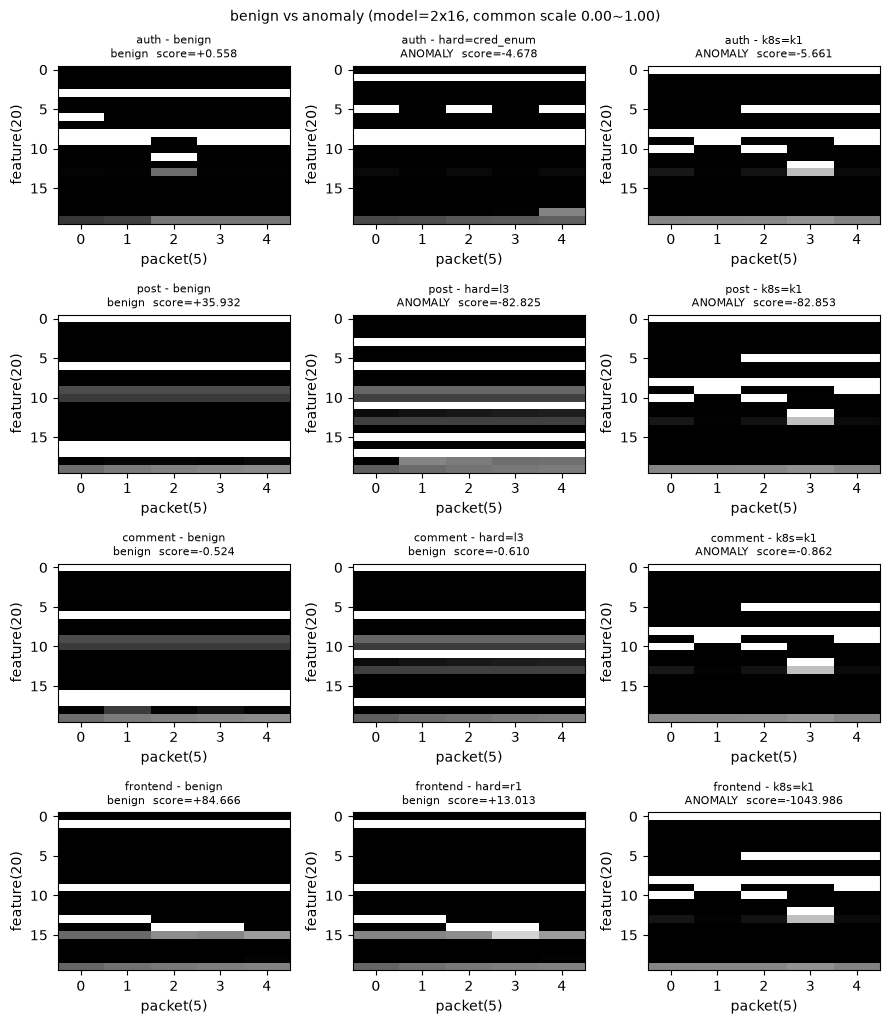

In [13]:
# 행: 서비스, 열: benign / hard / k8s

try:
    import matplotlib.pyplot as plt
except ImportError:
    print("matplotlib 미설치 -> 시각화 건너뜀")
else:
    assert "DETECTORS" in dir() and DETECTORS, "먼저 런타임 데모 셀을 실행"

    COL_TAGS = ["benign", "hard", "k8s"]

    # 서비스별 이미지 수집
    grid = {}
    for svc in SERVICES:
        det = DETECTORS[svc]
        row = {}

        try:
            _bp, _bsid, bev = select_benign_session(svc, det)
            if bev is not None and getattr(bev, "image", None) is not None:
                row["benign"] = bev
        except Exception as e:
            print(f"  [WARN] {svc} benign 실패: {e}")

        for tag in ("hard", "k8s"):
            scen, pref = SCEN[svc][tag]
            try:
                _ap, _asid, aev = select_attack_session(svc, det, scen, pref)
                if aev is not None and getattr(aev, "image", None) is not None:
                    row[tag] = aev
            except Exception as e:
                print(f"  [WARN] {svc}/{scen}({tag}) 실패: {e}")

        grid[svc] = row

    # 모든 이미지에 같은 밝기 범위 적용
    imgs = [ev.image for r in grid.values() for ev in r.values()]
    rows = [svc for svc in SERVICES if grid[svc]]

    if not imgs or not rows:
        print("표시할 이미지가 없습니다. (세션/pcap 확인)")
    else:
        vmin = float(min(im.min() for im in imgs))
        vmax = float(max(im.max() for im in imgs))

        fig, axes = plt.subplots(
            len(rows),
            3,
            figsize=(9, 2.6 * len(rows)),
            squeeze=False
        )

        for ri, svc in enumerate(rows):
            for ci, tag in enumerate(COL_TAGS):
                ax = axes[ri][ci]
                ev = grid[svc].get(tag)

                if ev is None:
                    ax.set_axis_off()
                    ax.set_title(
                        f"{svc} - {tag}\nimage not available",
                        fontsize=8
                    )
                    continue

                im = ev.image

                ax.imshow(
                    im,
                    aspect="auto",
                    cmap="gray",
                    vmin=vmin,
                    vmax=vmax
                )

                name = (
                    "benign"
                    if tag == "benign"
                    else f"{tag}={SCEN[svc][tag][0]}"
                )
                verdict = "benign" if ev.is_benign else "ANOMALY"

                ax.set_title(
                    f"{svc} - {name}\n"
                    f"{verdict}  score={ev.score:+.3f}",
                    fontsize=8
                )
                ax.set_xlabel(f"packet({im.shape[1]})")
                ax.set_ylabel(f"feature({im.shape[0]})")

        fig.suptitle(
            f"benign vs anomaly "
            f"(model={FIXED_ARCH}, common scale {vmin:.2f}~{vmax:.2f})",
            fontsize=10
        )

        plt.tight_layout()
        plt.show()

### 1x8 평가

In [42]:
if "1x8" in ARCHS:
    SWEEP["1x8"] = run_eval("1x8")
else:
    print("models_1x8/ 없음 : 건너뜀")

##############################################################################################################
### ARCH = 1x8   (models_root = c:\test\models_1x8)
### 재보정 안 된 서비스: ['auth', 'comment', 'frontend'], 학습 시점 임계값 유지
##############################################################################################################

세션 기반 런타임 평가 시작
attack image 정책: 4 benign + 1 attack / window=5 / stride=1

##############################################################################################################
 SERVICE: auth
##############################################################################################################
threshold = -2.236192

[benign]
  benign_auth.pcap: raw-egress=109831, kept=109831, sessions=888
  pure benign images = 106282 (실제 benign session 내부에서만 stride=1 생성)

[attack: mixed windows]
  scenario              raw     kept   sess  mixed-img       TP       FN    recall
  --------------------------------------------------------------------------

### 2x8 평가

In [43]:
if "2x8" in ARCHS:
    SWEEP["2x8"] = run_eval("2x8")
else:
    print("models_2x8/ 없음 : 건너뜀")

##############################################################################################################
### ARCH = 2x8   (models_root = c:\test\models_2x8)
### 재보정 안 된 서비스: ['comment'], 학습 시점 임계값 유지
##############################################################################################################

세션 기반 런타임 평가 시작
attack image 정책: 4 benign + 1 attack / window=5 / stride=1

##############################################################################################################
 SERVICE: auth
##############################################################################################################
threshold = -0.472404

[benign]
  benign_auth.pcap: raw-egress=109831, kept=109831, sessions=888
  pure benign images = 106282 (실제 benign session 내부에서만 stride=1 생성)

[attack: mixed windows]
  scenario              raw     kept   sess  mixed-img       TP       FN    recall
  ----------------------------------------------------------------------------------
  cred_enum

### 1x16 평가

In [44]:
if "1x16" in ARCHS:
    SWEEP["1x16"] = run_eval("1x16")
else:
    print("models_1x16/ 없음 : 건너뜀")

##############################################################################################################
### ARCH = 1x16   (models_root = c:\test\models_1x16)
### 재보정 안 된 서비스: ['comment', 'frontend'], 학습 시점 임계값 유지
##############################################################################################################

세션 기반 런타임 평가 시작
attack image 정책: 4 benign + 1 attack / window=5 / stride=1

##############################################################################################################
 SERVICE: auth
##############################################################################################################
threshold = -1.221465

[benign]
  benign_auth.pcap: raw-egress=109831, kept=109831, sessions=888
  pure benign images = 106282 (실제 benign session 내부에서만 stride=1 생성)

[attack: mixed windows]
  scenario              raw     kept   sess  mixed-img       TP       FN    recall
  --------------------------------------------------------------------------------

### 2x16 평가

In [45]:
if "2x16" in ARCHS:
    SWEEP["2x16"] = run_eval("2x16")
else:
    print("models_2x16/ 없음 : 건너뜀")

##############################################################################################################
### ARCH = 2x16   (models_root = c:\test\models_2x16)
##############################################################################################################

세션 기반 런타임 평가 시작
attack image 정책: 4 benign + 1 attack / window=5 / stride=1

##############################################################################################################
 SERVICE: auth
##############################################################################################################
threshold = -18.945084

[benign]
  benign_auth.pcap: raw-egress=109831, kept=109831, sessions=888
  pure benign images = 106282 (실제 benign session 내부에서만 stride=1 생성)

[attack: mixed windows]
  scenario              raw     kept   sess  mixed-img       TP       FN    recall
  ----------------------------------------------------------------------------------
  cred_enum            1150     1150     74       1

### 2x32 평가

In [46]:
if "2x32" in ARCHS:
    SWEEP["2x32"] = run_eval("2x32")
else:
    print("models_2x32/ 없음 : 건너뜀")

##############################################################################################################
### ARCH = 2x32   (models_root = c:\test\models_2x32)
### 재보정 안 된 서비스: ['auth', 'frontend'], 학습 시점 임계값 유지
##############################################################################################################

세션 기반 런타임 평가 시작
attack image 정책: 4 benign + 1 attack / window=5 / stride=1

##############################################################################################################
 SERVICE: auth
##############################################################################################################
threshold = -53.313554

[benign]
  benign_auth.pcap: raw-egress=109831, kept=109831, sessions=888
  pure benign images = 106282 (실제 benign session 내부에서만 stride=1 생성)

[attack: mixed windows]
  scenario              raw     kept   sess  mixed-img       TP       FN    recall
  ----------------------------------------------------------------------------------

## 결과 비교

서비스별 지표와 아키텍처별 합계를 비교한다.
`ROLLBK`의 Recall/FPR은 학습 시점 임계값 기준이다. 임계값과 무관한 성능은 AUC로 비교한다.

In [47]:
import numpy as np

if not SWEEP:
    print("아직 실행된 arch 가 없음")
else:
    # 서비스별 결과
    for svc in SERVICES:
        print(f"\n{'='*118}\n - {svc}\n{'='*118}")
        print(f"{'arch':8s}{'재보정':>8s}{'TP':>9s}{'FP':>9s}{'TN':>9s}{'FN':>9s}"
              f"{'Recall':>10s}{'FPR':>9s}{'AUC':>9s}")
        print("-" * 118)
        for arch in ARCHS:
            r = SWEEP.get(arch, {}).get(svc)
            if not r:
                print(f"{arch:8s}{'미실행':>8s}"); continue
            m = r["metrics"]
            st = "OK" if ARCH_STATUS[arch][svc]["recalibrated"] else "ROLLBK"
            print(f"{arch:8s}{st:>8s}{m['TP']:9d}{m['FP']:9d}{m['TN']:9d}{m['FN']:9d}"
                  f"{m['recall']*100:9.2f}%{m['fpr']*100:8.2f}%{m['auc']:9.4f}")

    # 아키텍처별 합계
    print(f"\n{'='*118}\n■ arch 전체 (4개 서비스 합계)\n{'='*118}")
    print(f"{'arch':8s}{'재보정OK':>10s}{'TP':>10s}{'FP':>10s}{'TN':>10s}{'FN':>10s}"
          f"{'Recall':>10s}{'FPR':>9s}{'meanAUC':>10s}{'worstAUC':>10s}")
    print("-" * 118)
    for arch in ARCHS:
        res = SWEEP.get(arch)
        if not res:
            print(f"{arch:8s}{'미실행':>10s}"); continue
        TP = sum(r["metrics"]["TP"] for r in res.values())
        FP = sum(r["metrics"]["FP"] for r in res.values())
        TN = sum(r["metrics"]["TN"] for r in res.values())
        FN = sum(r["metrics"]["FN"] for r in res.values())
        aucs = [r["metrics"]["auc"] for r in res.values()]
        n_ok = sum(1 for s in SERVICES if ARCH_STATUS[arch][s]["recalibrated"])
        rec = TP / (TP + FN) if (TP + FN) else float("nan")
        fpr = FP / (FP + TN) if (FP + TN) else float("nan")
        print(f"{arch:8s}{n_ok:>7d}/{len(SERVICES):<2d}{TP:10d}{FP:10d}{TN:10d}{FN:10d}"
              f"{rec*100:9.2f}%{fpr*100:8.2f}%{np.mean(aucs):10.4f}{min(aucs):10.4f}")



 - auth
arch         재보정       TP       FP       TN       FN    Recall      FPR      AUC
----------------------------------------------------------------------------------------------------------------------
1x8       ROLLBK     3375      818   105464    22356    13.12%    0.77%   0.7370
2x8           OK    23886     1947   104335     1845    92.83%    1.83%   0.9643
1x16          OK    24505     2133   104149     1226    95.24%    2.01%   0.9737
2x16          OK    23257     1657   104625     2474    90.39%    1.56%   0.9778
2x32      ROLLBK    23453     1984   104298     2278    91.15%    1.87%   0.9809

 - post
arch         재보정       TP       FP       TN       FN    Recall      FPR      AUC
----------------------------------------------------------------------------------------------------------------------
1x8           OK     6932        0     1376    12905    34.94%    0.00%   0.9518
2x8           OK    19666        7     1369      171    99.14%    0.51%   0.9986
1x16          O